# Xarray-Spatial Interpolation: GeoDataFrames, the `.xrs` accessor, and coregistration

Field measurements rarely arrive as a tidy grid. You get a GeoDataFrame of
sample points, each with a value and a coordinate reference system, and you
want a continuous surface that lines up with a raster you already have. This
notebook turns a GeoDataFrame of points straight into an interpolated surface,
calls the interpolators on the `.xrs` accessor so the output inherits the
caller raster's grid and CRS, and reprojects points across coordinate systems
with `coregister=True`.

### What you'll build

1. Build a GeoDataFrame of sample points with a value column
2. Interpolate it onto a target grid with `idw`, passing the GeoDataFrame directly
3. Run `kriging` and `spline` from the `.xrs` accessor so the output matches the caller raster
4. Map point density with `kde`
5. Reproject points from EPSG:4326 into the grid's EPSG:3857 with `coregister=True`

![Vector interpolation preview](images/vector_interpolation_preview.png)

[IDW from a GeoDataFrame](#IDW-from-a-GeoDataFrame) ·
[The .xrs accessor](#The-.xrs-accessor:-kriging-and-spline) ·
[Point density with KDE](#Point-density-with-KDE) ·
[Coregistration across CRSs](#Coregistration-across-CRSs)

Standard imports plus geopandas for the point data and the xrspatial interpolators. Importing `xrspatial` registers the `.xrs` accessor.

In [1]:
import numpy as np
import xarray as xr
import geopandas as gpd
from shapely.geometry import Point

import matplotlib.pyplot as plt
from matplotlib.patches import Patch

import xrspatial  # registers the .xrs accessor
from xrspatial import idw

## Sample points as a GeoDataFrame

We scatter sixty measurement points across a small area near San Francisco and
give each one a value that follows a smooth gradient with a warm pocket in the
middle, the kind of pattern a temperature or pollutant survey might show. The
points start in longitude/latitude (EPSG:4326).

In [2]:
rng = np.random.default_rng(42)

# Random points in a lon/lat box near San Francisco
lon = rng.uniform(-122.45, -122.35, 60)
lat = rng.uniform(37.74, 37.82, 60)

# Smooth field: west-to-east gradient plus a warm bump in the centre
xc = (lon + 122.45) / 0.10
yc = (lat - 37.74) / 0.08
value = (12 + 8 * xc
         + 10 * np.exp(-(((xc - 0.5) ** 2 + (yc - 0.5) ** 2) / 0.05)))

points = gpd.GeoDataFrame(
    {"temperature": value},
    geometry=[Point(a, b) for a, b in zip(lon, lat)],
    crs="EPSG:4326",
)

# A projected copy (Web Mercator, metres) for the same-CRS examples
points_3857 = points.to_crs("EPSG:3857")
points.head()

,temperature,geometry
0,19.455742,POINT (-122.3726 37.79347)
1,24.637321,POINT (-122.40611 37.77769)
2,19.570392,POINT (-122.36414 37.78522)
3,18.705330,POINT (-122.38026 37.8012)
4,13.011563,POINT (-122.44058 37.79078)


## A target grid

The output surface needs a grid to land on. We build an empty raster in
EPSG:3857 (metres) that covers the points, with `y` descending and a `crs`
attribute. This is the "caller" raster the accessor reads its grid and CRS
from.

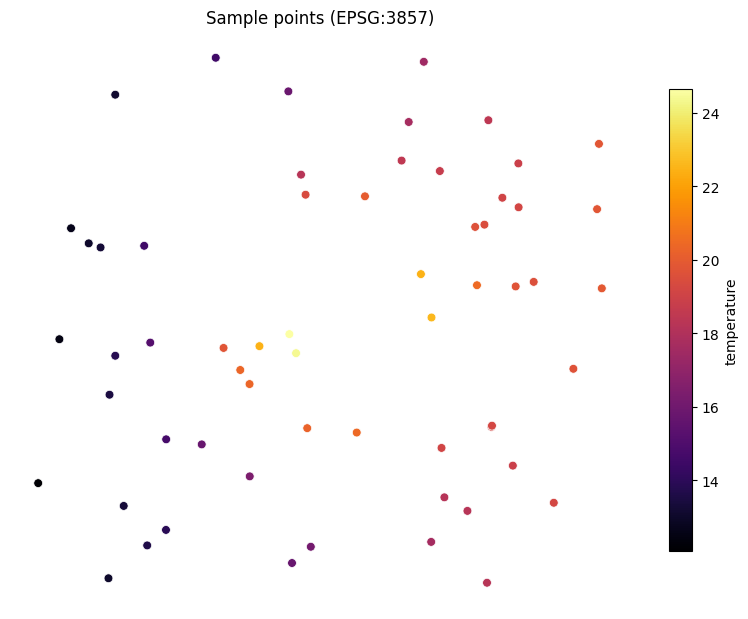

In [3]:
xmin, ymin, xmax, ymax = points_3857.total_bounds
pad_x, pad_y = 0.05 * (xmax - xmin), 0.05 * (ymax - ymin)

xs = np.linspace(xmin - pad_x, xmax + pad_x, 160)
ys = np.linspace(ymax + pad_y, ymin - pad_y, 130)  # descending
grid = xr.DataArray(
    np.zeros((ys.size, xs.size)),
    coords={"y": ys, "x": xs}, dims=["y", "x"],
    attrs={"crs": "EPSG:3857"},
)

fig, ax = plt.subplots(figsize=(10, 7.5))
sc = ax.scatter(points_3857.geometry.x, points_3857.geometry.y,
                c=points_3857["temperature"], cmap="inferno", s=40,
                edgecolor="white", linewidth=0.5)
fig.colorbar(sc, ax=ax, shrink=0.8, label="temperature")
ax.set_title("Sample points (EPSG:3857)")
ax.set_axis_off()

## IDW from a GeoDataFrame

Every interpolator now accepts a GeoDataFrame as its first argument. The
`column` argument picks the value to interpolate, exactly like `rasterize`. Pass
the grid as `template` and the result lands on that grid. Inverse distance
weighting fills each cell from a distance-weighted average of nearby points.

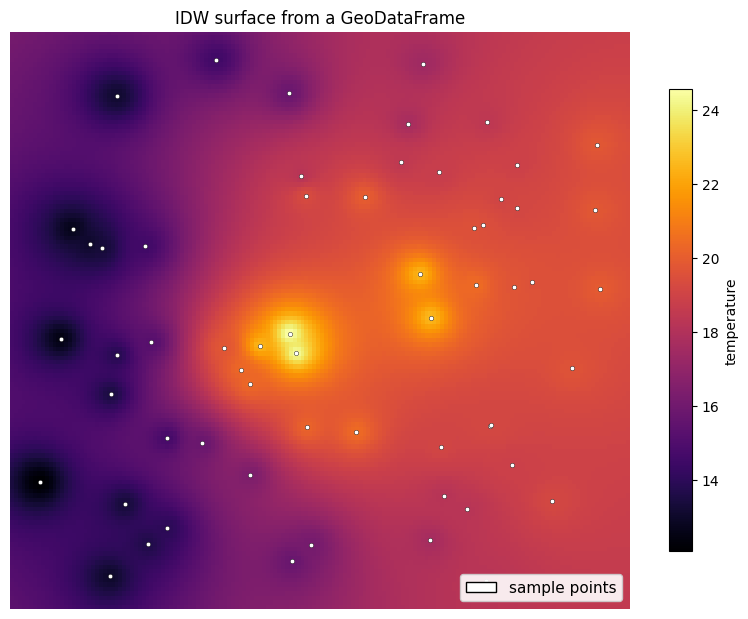

In [4]:
idw_surface = idw(points_3857, template=grid, column="temperature")

fig, ax = plt.subplots(figsize=(10, 7.5))
idw_surface.plot.imshow(ax=ax, cmap="inferno", add_colorbar=True,
                        cbar_kwargs={"shrink": 0.8, "label": "temperature"})
ax.scatter(points_3857.geometry.x, points_3857.geometry.y, s=10,
           c="white", edgecolor="black", linewidth=0.3)
ax.legend(handles=[Patch(facecolor="white", edgecolor="black",
                         label="sample points")],
          loc="lower right", fontsize=11, framealpha=0.9)
ax.set_title("IDW surface from a GeoDataFrame")
ax.set_axis_off()

## The `.xrs` accessor: kriging and spline

The same operations hang off the `.xrs` accessor. Called this way, the caller
raster *is* the template, so the output inherits its grid, chunks, and CRS with
no `template=` argument. Here are ordinary kriging and a thin plate spline side
by side.

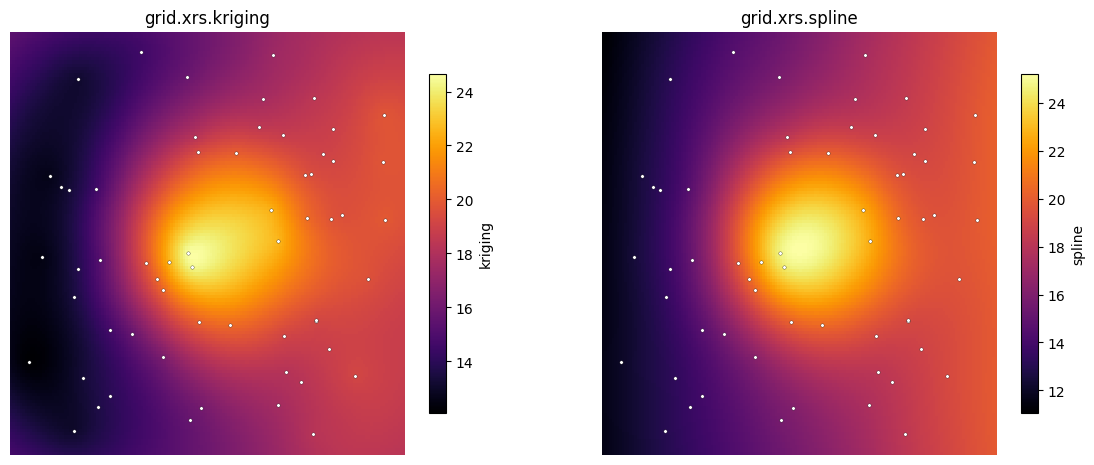

In [5]:
krig_surface = grid.xrs.kriging(points_3857, column="temperature")
spline_surface = grid.xrs.spline(points_3857, column="temperature")

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for ax, surf, title in [(axes[0], krig_surface, "grid.xrs.kriging"),
                        (axes[1], spline_surface, "grid.xrs.spline")]:
    surf.plot.imshow(ax=ax, cmap="inferno", add_colorbar=True,
                     cbar_kwargs={"shrink": 0.8})
    ax.scatter(points_3857.geometry.x, points_3857.geometry.y, s=6,
               c="white", edgecolor="black", linewidth=0.2)
    ax.set_title(title)
    ax.set_axis_off()

## Point density with KDE

`kde` measures where points cluster rather than interpolating a value, so it
needs no column for a plain density. On the accessor it reports density on the
caller grid. Pass `column=` to weight each point instead.

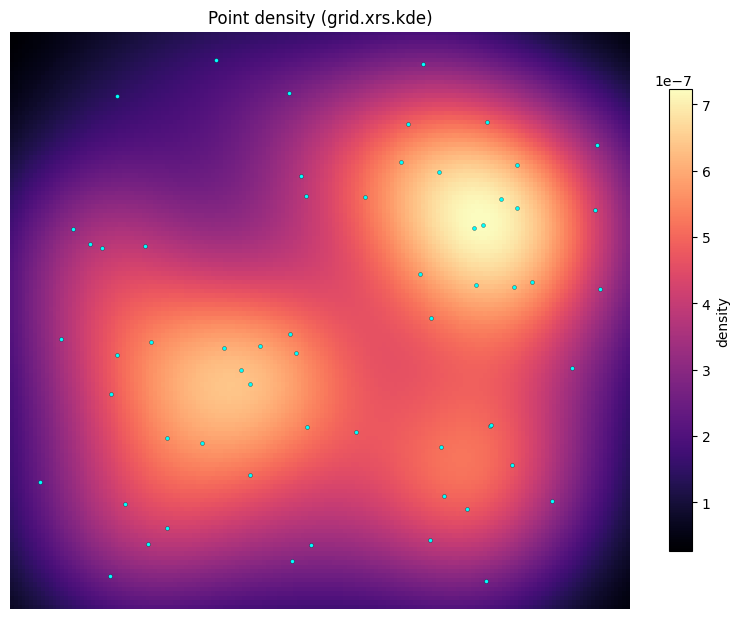

In [6]:
density = grid.xrs.kde(points_3857)

fig, ax = plt.subplots(figsize=(10, 7.5))
density.plot.imshow(ax=ax, cmap="magma", add_colorbar=True,
                    cbar_kwargs={"shrink": 0.8, "label": "density"})
ax.scatter(points_3857.geometry.x, points_3857.geometry.y, s=8,
           c="cyan", edgecolor="black", linewidth=0.2)
ax.set_title("Point density (grid.xrs.kde)")
ax.set_axis_off()

## Coregistration across CRSs

The headline case: your points are in one CRS and your raster is in another.
With `coregister=True` the accessor reprojects the points from their CRS into
the caller's CRS before interpolating, the same idea as
`open_geotiff(coregister=True)` for rasters. Below, the original points are in
EPSG:4326 while the grid is in EPSG:3857. The coregistered result matches the
surface we got from the already-projected points.

max difference vs pre-projected points: 0.00e+00


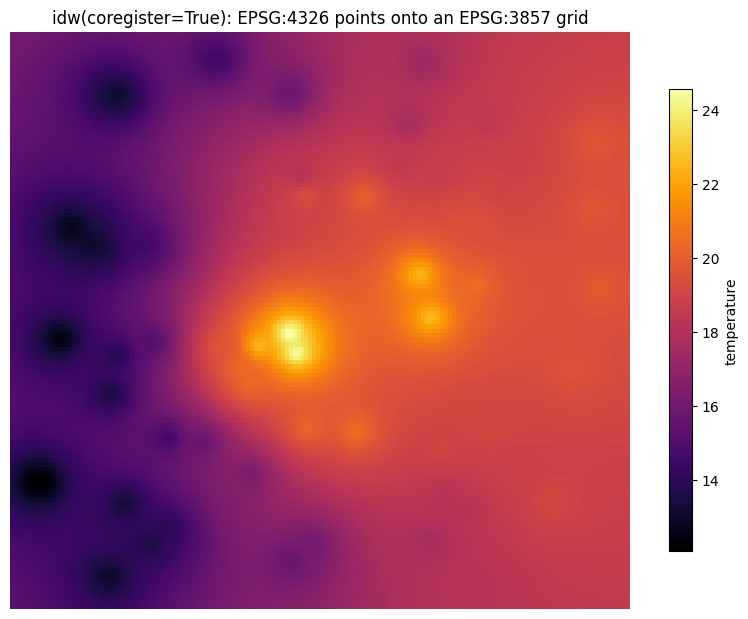

In [7]:
# `points` is still in EPSG:4326; `grid` is EPSG:3857
coreg = grid.xrs.idw(points, column="temperature", coregister=True)

# Same result as interpolating the pre-projected points
direct = grid.xrs.idw(points_3857, column="temperature")
max_diff = float(np.nanmax(np.abs(coreg.values - direct.values)))
print(f"max difference vs pre-projected points: {max_diff:.2e}")

fig, ax = plt.subplots(figsize=(10, 7.5))
coreg.plot.imshow(ax=ax, cmap="inferno", add_colorbar=True,
                  cbar_kwargs={"shrink": 0.8, "label": "temperature"})
ax.set_title("idw(coregister=True): EPSG:4326 points onto an EPSG:3857 grid")
ax.set_axis_off()

<div class="alert alert-block alert-warning">
<b>Coregistration needs a CRS on both sides.</b> The points carry their CRS in
<code>GeoDataFrame.crs</code> and the caller raster carries its CRS in
<code>attrs['crs']</code>. With <code>coregister=False</code> (the default), a
genuine CRS mismatch raises instead of silently interpolating in the wrong
units. Set the CRS on both before reprojecting.
</div>

### References

- [Inverse distance weighting](https://en.wikipedia.org/wiki/Inverse_distance_weighting)
- [Kriging](https://en.wikipedia.org/wiki/Kriging)
- [Thin plate spline](https://en.wikipedia.org/wiki/Thin_plate_spline)
- [Kernel density estimation](https://en.wikipedia.org/wiki/Kernel_density_estimation)
- [GeoPandas coordinate reference systems](https://geopandas.org/en/stable/docs/user_guide/projections.html)